# Predicting Employee Attrition Using Machine Learning


## OMIS 3020 R - Predictive Analytics
####Team: Adam Jaffar, Uddam Bhathal, Shervin Maadani, Md Nafeez


##Research Question and Objectives

####Problem Statement:
Employee attrition is the voluntary exit of an employee from an organization. Regardless of the industry, this remains a challenge for every business. Studies, for example, state that for an employer to replace an employee, the cost would range from 50% to 200% of that employee's salary, due to the cost of recruitment, onboarding, and impact on productivity. Despite this, most organizations respond to employee attrition reactively, and for the most part, it's too late.
Predictive analytics offers a proactive alternative: by identifying at-risk employees before they resign, HR teams can intervene with targeted retention strategies. This project is relevant to virtually every organization and presents an analytically rich binary classification problem involving imbalanced classes, interpretability requirements, and actionable business insights.


#### Research Questions:

1. Can we accurately predict whether an employee will leave the organization using HR and demographic features?

2. Which factors (e.g., overtime, job satisfaction, years at company, salary) are the strongest predictors of attrition?

3. How does addressing class imbalance through class weighting affect model performance and recall on at-risk employees?

4. Do different employee segments (e.g., job role, department) exhibit distinct attrition risk profiles?


## 0: Import libraries

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_curve, auc, make_scorer, precision_recall_curve, average_precision_score

from xgboost import XGBClassifier

from IPython.display import display
plt.style.use('default')
pd.set_option('display.max_columns', 100)

## 1. Load dataset

In [76]:
try:
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
except:
    df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (1).csv


We set up the backup method incase you run outside of google colab

## 2: Data overview

Confirming there are no missing values in the dataset

In [77]:
print("Total missing values in dataset:", df.isnull().sum().sum())

Total missing values in dataset: 0


In [78]:

print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nAttrition counts:")
print(df["Attrition"].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Shape of dataset: (1470, 35)

Column names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Attrition counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Missing values:
Age                 0
Attrition           0
BusinessTravel      0
DailyRate           0
Department          0
DistanceFromHome    0
Education           0
EducationField      0
EmployeeCount       0
EmployeeNumber      0
dtype: int64


####Checking the data types

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

##3. Data Cleaning

In [80]:
cols_to_drop = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
df = df.drop(columns=cols_to_drop)

#Creating a binary target variable
df["Attrition_Flag"] = df["Attrition"].map({"No": 0, "Yes": 1})

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Flag
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2,0


##4. EDA

###4.1 Overall attrition rate

In [81]:
attrition_rate = df["Attrition_Flag"].mean() * 100
print(f"Overall attrition rate: {attrition_rate:.2f}%")

Overall attrition rate: 16.12%


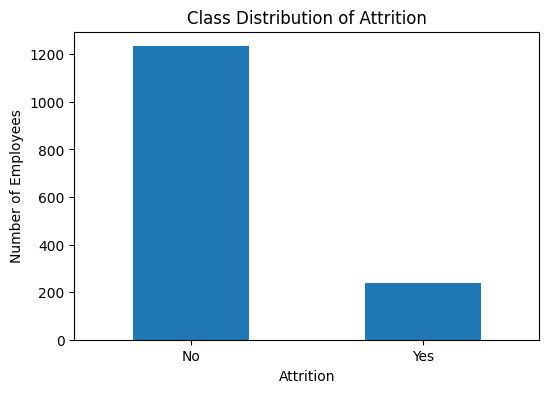

In [82]:
attrition_counts = df["Attrition"].value_counts()

plt.figure(figsize=(6, 4))
attrition_counts.plot(kind="bar")
plt.title("Class Distribution of Attrition")
plt.ylabel("Number of Employees")
plt.xlabel("Attrition")
plt.xticks(rotation=0)
plt.show()

### 4.2 Attrition rate by dept

,Attrition_Flag
Department,
Sales,20.63
Human Resources,19.05
Research & Development,13.84


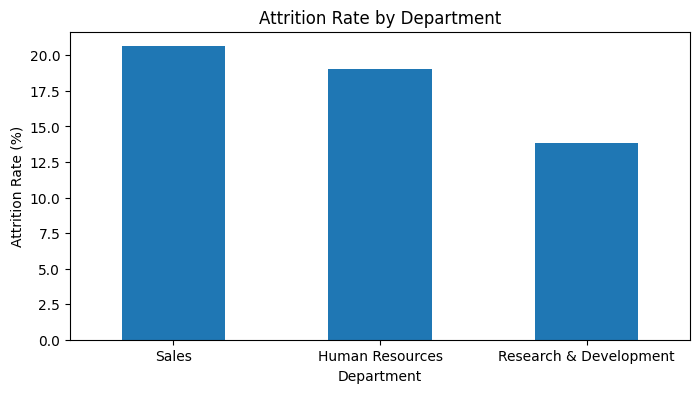

In [83]:
dept_risk = (df.groupby("Department")["Attrition_Flag"].mean().sort_values(ascending=False) * 100)

display(dept_risk.round(2))

plt.figure(figsize=(8, 4))
dept_risk.plot(kind="bar")
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")
plt.xticks(rotation=0)
plt.show()

### 4.3 Attrition rate by job role

,Attrition_Flag
JobRole,
Sales Representative,39.76
Laboratory Technician,23.94
Human Resources,23.08
Sales Executive,17.48
Research Scientist,16.10
Manufacturing Director,6.90
Healthcare Representative,6.87
Manager,4.90
Research Director,2.50


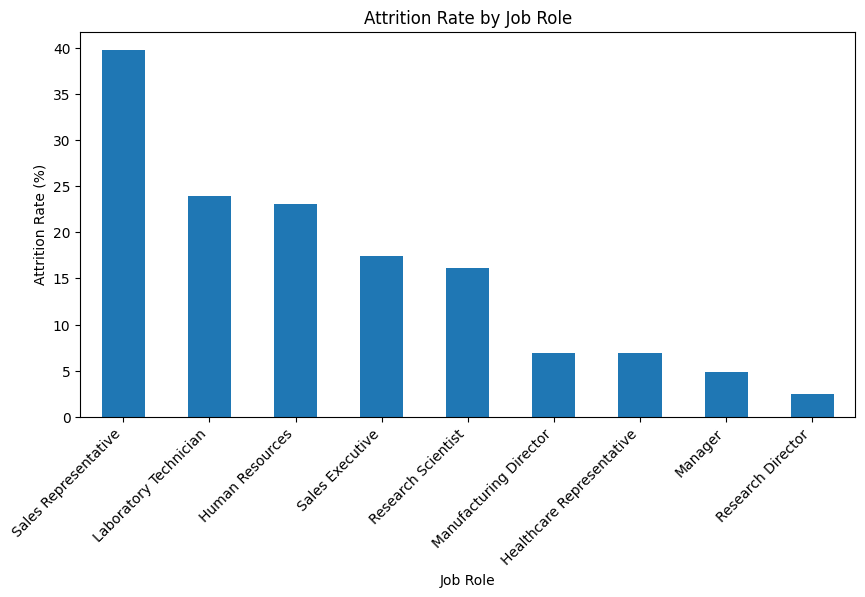

In [84]:
jobrole_risk = (df.groupby("JobRole")["Attrition_Flag"].mean().sort_values(ascending=False) * 100)

display(jobrole_risk.round(2))

plt.figure(figsize=(10, 5))
jobrole_risk.plot(kind="bar")
plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Job Role")
plt.xticks(rotation=45, ha="right")
plt.show()

### 4.4 Overtime vs Attrition
(Each row adds up to 100%...Ex. OverTime = No: 89.56% employees stayed (Attrition = No and 10.44% left (Attrition = Yes))

In [85]:
overtime_attrition = pd.crosstab(df["OverTime"],df["Attrition"],normalize="index") * 100

display(overtime_attrition.round(2))

Attrition,No,Yes
OverTime,,
No,89.56,10.44
Yes,69.47,30.53


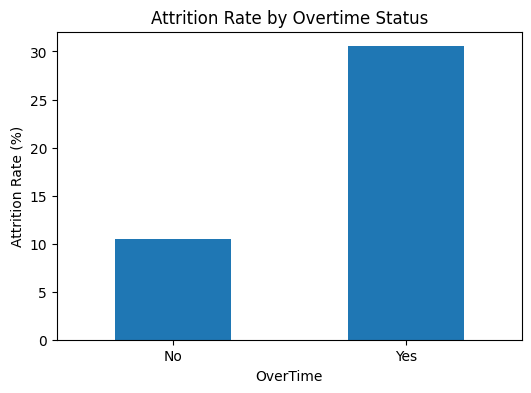

In [86]:
overtime_yes_rate = df.groupby("OverTime")["Attrition_Flag"].mean() * 100

plt.figure(figsize=(6, 4))
overtime_yes_rate.plot(kind="bar")
plt.title("Attrition Rate by Overtime Status")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("OverTime")
plt.xticks(rotation=0)
plt.show()

Employees who work overtime have a much higher attrition rate than those who do not, suggesting overtime is an important warning sign for employee turnover.

### 4.5 Attrition rate by job satisfaction

Attrition rate by job satisfaction:


,Attrition_Flag
JobSatisfaction,
1,22.84
2,16.43
3,16.52
4,11.33


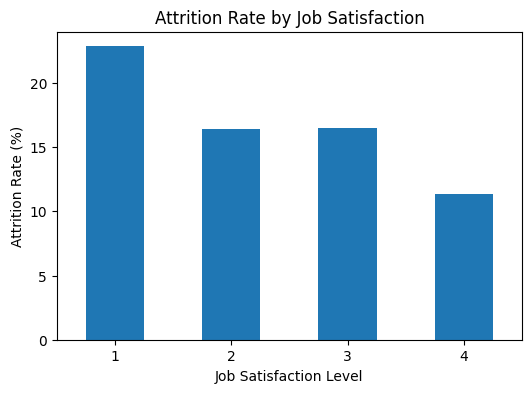

In [87]:
job_sat_risk = df.groupby("JobSatisfaction")["Attrition_Flag"].mean() * 100

print("Attrition rate by job satisfaction:")
display(job_sat_risk.round(2))

plt.figure(figsize=(6, 4))
job_sat_risk.plot(kind="bar")
plt.title("Attrition Rate by Job Satisfaction")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Job Satisfaction Level")
plt.xticks(rotation=0)
plt.show()

Employees with lower job satisfaction tend to show higher attrition risk, which supports the idea that disengagement is linked to turnover.

### 4.6 Income and attrition

/tmp/ipykernel_1986/1825813027.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([income_stayed, income_left], labels=["Stayed", "Left"])


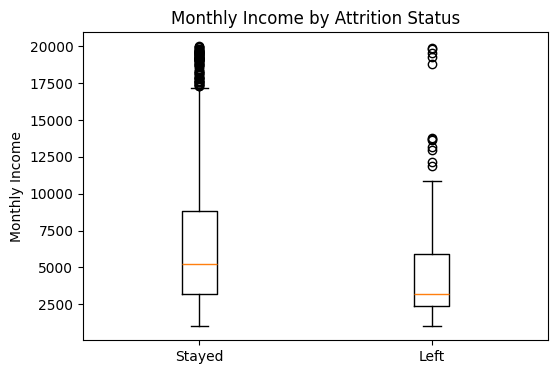

In [88]:
income_stayed = df[df["Attrition"] == "No"]["MonthlyIncome"]
income_left = df[df["Attrition"] == "Yes"]["MonthlyIncome"]

plt.figure(figsize=(6, 4))
plt.boxplot([income_stayed, income_left], labels=["Stayed", "Left"])
plt.title("Monthly Income by Attrition Status")
plt.ylabel("Monthly Income")
plt.show()

This plot helps compare the income distribution of employees who stayed versus those who left. If the “Left” group is generally lower, that supports compensation as a retention factor.

### 4.7 Tenure and attrition

/tmp/ipykernel_1986/3154177638.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([years_stayed, years_left], labels=["Stayed", "Left"])


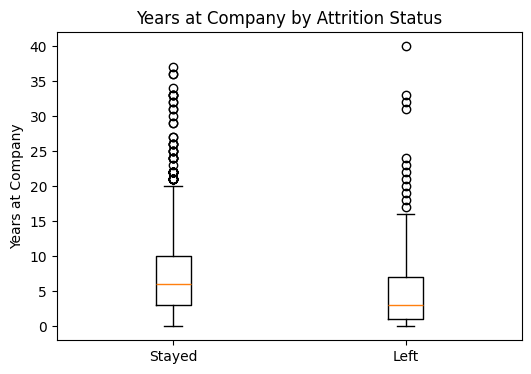

In [89]:
years_stayed = df[df["Attrition"] == "No"]["YearsAtCompany"]
years_left = df[df["Attrition"] == "Yes"]["YearsAtCompany"]

plt.figure(figsize=(6, 4))
plt.boxplot([years_stayed, years_left], labels=["Stayed", "Left"])
plt.title("Years at Company by Attrition Status")
plt.ylabel("Years at Company")
plt.show()

This plot shows whether employees who leave tend to have shorter tenure, which can help HR identify when turnover risk is highest.

###4.8 Correlation of key variables

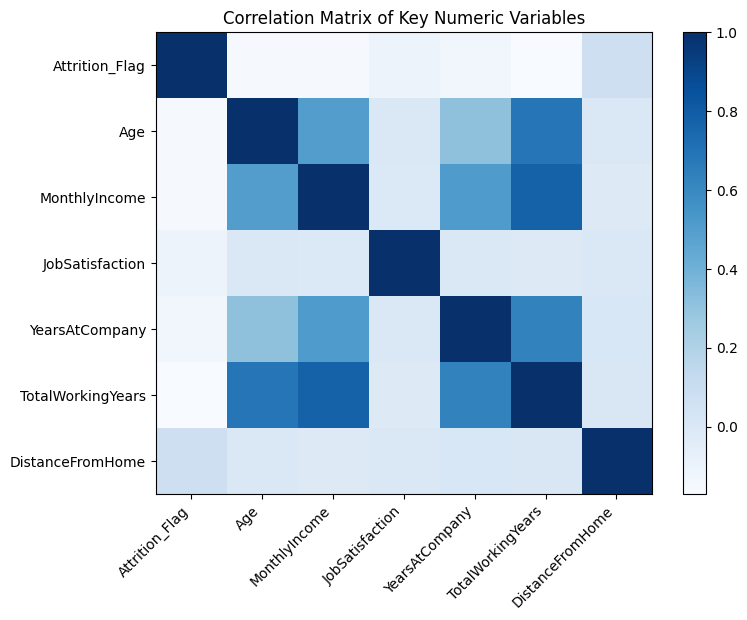

In [90]:
corr_cols = ["Attrition_Flag", "Age", "MonthlyIncome", "JobSatisfaction", "YearsAtCompany", "TotalWorkingYears", "DistanceFromHome"]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="Blues", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Matrix of Key Numeric Variables")
plt.show()

## 5: Building model

###5.1 Defining X and y

In [91]:
X = df.drop(columns=["Attrition", "Attrition_Flag"])
y = df["Attrition_Flag"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

### 5.2 Train test split

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,stratify=y,random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining attrition rate:", round(y_train.mean(), 4))
print("Test attrition rate:", round(y_test.mean(), 4))

Training set shape: (1176, 30)
Test set shape: (294, 30)

Training attrition rate: 0.1616
Test attrition rate: 0.1599


###5.3 Preprocessing

In [93]:
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])

categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer(transformers=[("num", numeric_transformer, numerical_cols),("cat", categorical_transformer, categorical_cols)])

###5.4 Handle class imbalance

In [94]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print("Negative cases:", neg_count)
print("Positive cases:", pos_count)
print("scale_pos_weight:", round(scale_pos_weight, 2))

Negative cases: 986
Positive cases: 190
scale_pos_weight: 5.19


###5.5 Defining models

Building a pipeline for effiency

In [95]:
baseline_models = {
    "Logistic Regression (No Class Weight)": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree (No Class Weight)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest (No Class Weight)": RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42, n_jobs=-1)}

weighted_models = {
    "Logistic Regression (Balanced)": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Decision Tree (Balanced)": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "Random Forest (Balanced)": RandomForestClassifier(n_estimators=150, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1)}

boosting_models = {
    "Gradient Boosting (XGBoost)": XGBClassifier(
        n_estimators=120,max_depth=3,learning_rate=0.05,subsample=0.9,
        colsample_bytree=0.9,scale_pos_weight=scale_pos_weight,eval_metric="logloss",random_state=42)}

models = {}
models.update(baseline_models)
models.update(weighted_models)
models.update(boosting_models)

### 5.6 Evaluate models

Building a function to evaluate each model

We use Statified 5-fold CV on the training set and final test metrics on the untouched test set

In [96]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):

    pipe = Pipeline(steps=[("preprocess", preprocess),("model", model)])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scoring = {"accuracy": "accuracy",
               "precision": make_scorer(precision_score, zero_division=0),
               "recall": make_scorer(recall_score, zero_division=0),
               "f1": make_scorer(f1_score, zero_division=0),
               "roc_auc": "roc_auc"}

    cv_scores = cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring,n_jobs=None)

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    result_row = {
        "Model": model_name,
        "CV Accuracy": cv_scores["test_accuracy"].mean(),
        "CV Precision": cv_scores["test_precision"].mean(),
        "CV Recall": cv_scores["test_recall"].mean(),
        "CV F1": cv_scores["test_f1"].mean(),
        "CV ROC AUC": cv_scores["test_roc_auc"].mean(),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred, zero_division=0),
        "Test F1": f1_score(y_test, y_pred, zero_division=0),
        "Test ROC AUC": roc_auc_score(y_test, y_prob)}
    return pipe, result_row

Running all of the models

In [97]:
saved_models = {}
results = []

for model_name, model in models.items():
    fitted_pipe, result_row = evaluate_model(model_name,model,X_train,X_test,y_train,y_test)
    saved_models[model_name] = fitted_pipe
    results.append(result_row)

## 6. Model evaluation

### 6.1 Model comparison

In [98]:
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by="CV F1", ascending=False).reset_index(drop=True)

summary_cols = ["Model", "CV F1", "CV ROC AUC", "CV Recall","Test F1", "Test ROC AUC", "Test Recall"]

print("Final model comparison (sorted by CV F1):")
display(results_df_sorted[summary_cols].round(4))

Final model comparison (sorted by CV F1):


,Model,CV F1,CV ROC AUC,CV Recall,Test F1,Test ROC AUC,Test Recall
0,Logistic Regression (No Class Weight),0.5610,0.8392,0.4421,0.4384,0.8115,0.3404
1,Gradient Boosting (XGBoost),0.5194,0.8116,0.6000,0.4444,0.7728,0.5106
2,Logistic Regression (Balanced),0.4925,0.8273,0.7368,0.4511,0.8032,0.6383
3,Decision Tree (No Class Weight),0.3699,0.6658,0.3053,0.2727,0.6618,0.1915
4,Random Forest (Balanced),0.3627,0.7907,0.2474,0.2899,0.7923,0.2128
5,Decision Tree (Balanced),0.3315,0.6264,0.4684,0.4425,0.6527,0.5319
6,Random Forest (No Class Weight),0.2855,0.8129,0.1789,0.1786,0.7974,0.1064


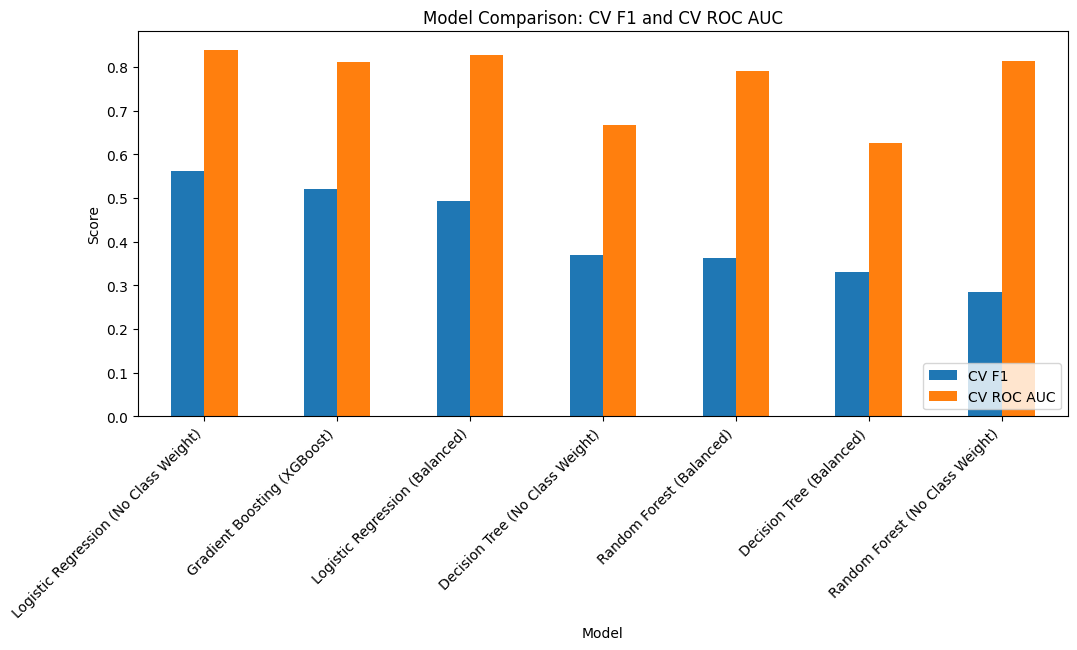

In [99]:
plot_df = results_df_sorted.set_index("Model")[["CV F1", "CV ROC AUC"]]

plot_df.plot(kind="bar", figsize=(12, 5))
plt.title("Model Comparison: CV F1 and CV ROC AUC")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.show()

###6.2 Effect of class weighting

In [100]:
class_weight_compare = results_df_sorted[
    results_df_sorted["Model"].isin([
        "Logistic Regression (No Class Weight)",
        "Logistic Regression (Balanced)",
        "Decision Tree (No Class Weight)",
        "Decision Tree (Balanced)",
        "Random Forest (No Class Weight)",
        "Random Forest (Balanced)"])][["Model", "CV Recall", "CV F1", "Test Recall", "Test F1"]]

print("Effect of class weighting on recall and F1:")
display(class_weight_compare.round(4))

Effect of class weighting on recall and F1:


,Model,CV Recall,CV F1,Test Recall,Test F1
0,Logistic Regression (No Class Weight),0.4421,0.5610,0.3404,0.4384
2,Logistic Regression (Balanced),0.7368,0.4925,0.6383,0.4511
3,Decision Tree (No Class Weight),0.3053,0.3699,0.1915,0.2727
4,Random Forest (Balanced),0.2474,0.3627,0.2128,0.2899
5,Decision Tree (Balanced),0.4684,0.3315,0.5319,0.4425
6,Random Forest (No Class Weight),0.1789,0.2855,0.1064,0.1786


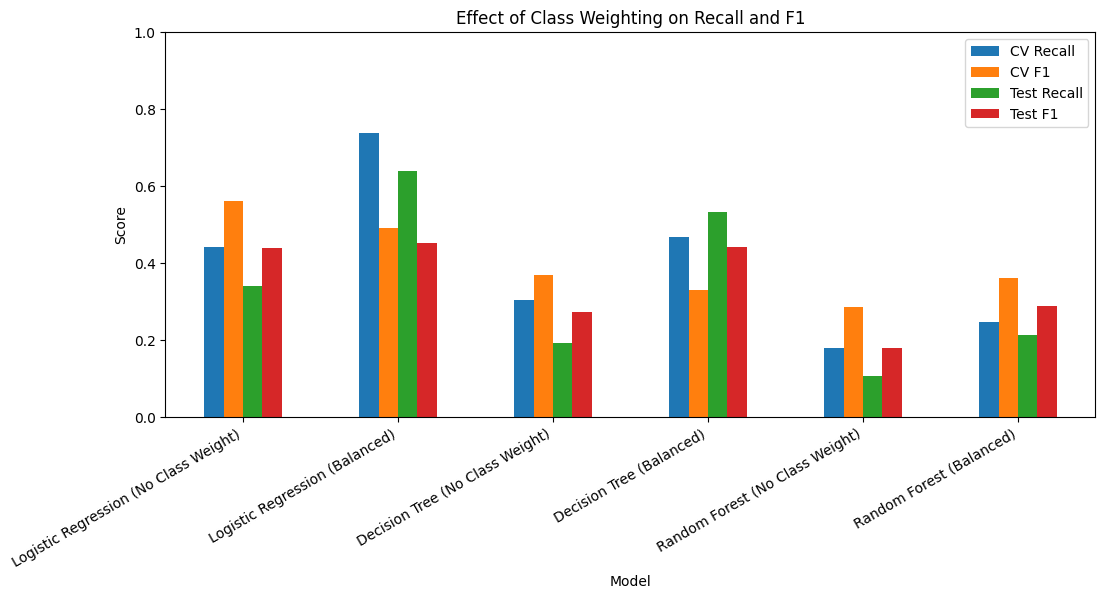

In [101]:
order = ["Logistic Regression (No Class Weight)","Logistic Regression (Balanced)","Decision Tree (No Class Weight)","Decision Tree (Balanced)","Random Forest (No Class Weight)","Random Forest (Balanced)"]

class_weight_plot = class_weight_compare.set_index("Model").loc[order]

ax = class_weight_plot[["CV Recall", "CV F1", "Test Recall", "Test F1"]].plot(kind="bar",figsize=(12, 5))

plt.title("Effect of Class Weighting on Recall and F1")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(loc="upper right")
plt.show()

This chart shows that class weighting generally improves recall, meaning the model catches more at-risk employees, but sometimes at the cost of lower overall balance in F1-score.

### 6.3 Best model performance

In [102]:
best_model_name = results_df_sorted.iloc[0]["Model"]
best_pipe = saved_models[best_model_name]

print("Best model based on CV F1:", best_model_name)

Best model based on CV F1: Logistic Regression (No Class Weight)


Classification report for the best model

In [103]:
best_pred = best_pipe.predict(X_test)
best_prob = best_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, best_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



Confusion matrix for the best model

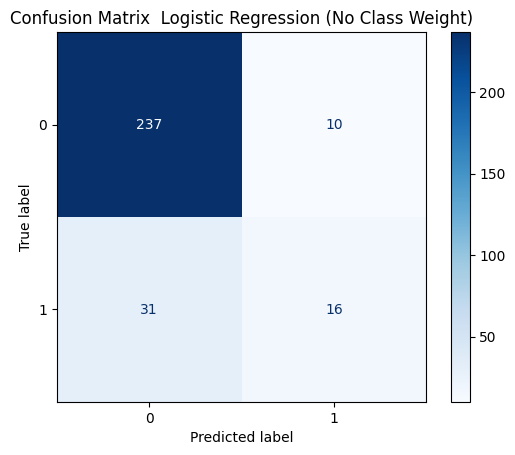

In [104]:
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix  {best_model_name}")
plt.show()

###6.4 ROC Curve of all models

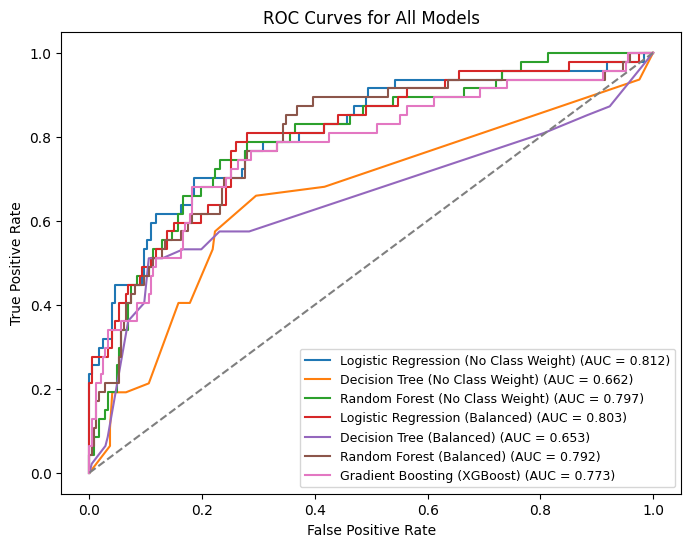

In [105]:
plt.figure(figsize=(8, 6))

for model_name, model_pipe in saved_models.items():
    y_prob = model_pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves for All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=9)
plt.show()

The ROC curve comparison shows how well each model separates employees who leave from those who stay across different classification thresholds. Models with curves closer to the top-left corner and higher AUC values demonstrate stronger overall classification performance.

The dashed diagonal line shows the performance of a random classifier. Any model above this line is performing better than random guessing.

###6.5 Precision-recall curve for all of the models

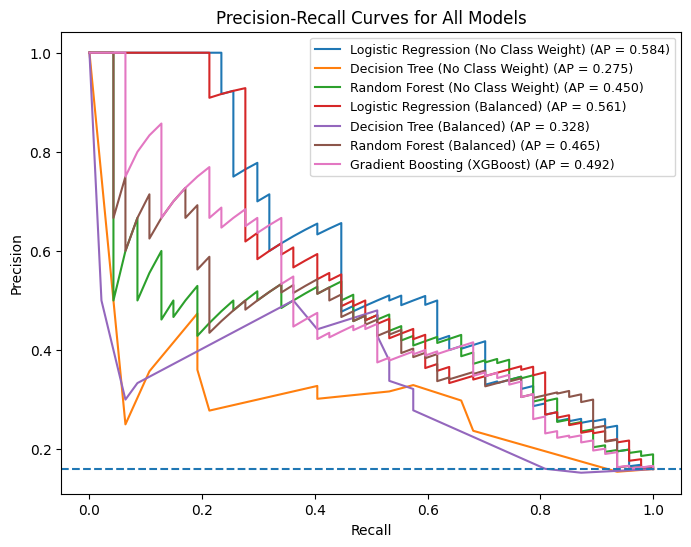

In [106]:
plt.figure(figsize=(8, 6))

for model_name, model_pipe in saved_models.items():
    y_prob = model_pipe.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap_score = average_precision_score(y_test, y_prob)

    plt.plot(recall, precision, label=f"{model_name} (AP = {ap_score:.3f})")

baseline = y_test.mean()
plt.axhline(y=baseline, linestyle="--")

plt.title("Precision-Recall Curves for All Models")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="upper right", fontsize=9)
plt.show()

Models with curves closer to the top-right and higher average precision scores perform better at identifying employees who leave while limiting false positives.

The dashed horizontal line shows the baseline precision, which is basically the positive-class rate in the test set.

## 7. Interpretation of Findings

### 7.1 Logistic Regression interpretation

In [107]:
log_pipe = saved_models["Logistic Regression (Balanced)"]

feature_names = log_pipe.named_steps["preprocess"].get_feature_names_out()
log_coefficients = log_pipe.named_steps["model"].coef_[0]

log_coef_df = pd.DataFrame({"Feature": feature_names,"Coefficient": log_coefficients})

log_coef_df["Odds_Ratio"] = np.exp(log_coef_df["Coefficient"])
log_coef_df["Abs_Coefficient"] = log_coef_df["Coefficient"].abs()

log_coef_df["Feature"] = (log_coef_df["Feature"].str.replace("num__", "", regex=False).str.replace("cat__", "", regex=False))

print("Top positive predictors of attrition:")
display(log_coef_df.sort_values("Coefficient", ascending=False).head(10))

print("Top negative predictors of attrition:")
display(log_coef_df.sort_values("Coefficient", ascending=True).head(10))

Top positive predictors of attrition:


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
39,JobRole_Laboratory Technician,1.194333,3.301354,1.194333
45,JobRole_Sales Representative,1.120617,3.066745,1.120617
24,BusinessTravel_Travel_Frequently,0.787566,2.198041,0.787566
50,OverTime_Yes,0.761522,2.141533,0.761522
29,EducationField_Human Resources,0.721129,2.056754,0.721129
7,JobLevel,0.607426,1.835700,0.607426
21,YearsSinceLastPromotion,0.502531,1.652899,0.502531
38,JobRole_Human Resources,0.463886,1.590242,0.463886
11,NumCompaniesWorked,0.460496,1.584859,0.460496
48,MaritalStatus_Single,0.457277,1.579767,0.457277


Top negative predictors of attrition:


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
42,JobRole_Research Director,-1.465683,0.230920,1.465683
23,BusinessTravel_Non-Travel,-0.993885,0.370136,0.993885
49,OverTime_No,-0.892809,0.409504,0.892809
33,EducationField_Other,-0.798108,0.450180,0.798108
37,JobRole_Healthcare Representative,-0.647202,0.523509,0.647202
16,TotalWorkingYears,-0.620234,0.537818,0.620234
46,MaritalStatus_Divorced,-0.482231,0.617405,0.482231
22,YearsWithCurrManager,-0.454674,0.634655,0.454674
4,EnvironmentSatisfaction,-0.426185,0.652996,0.426185
8,JobSatisfaction,-0.388876,0.677818,0.388876


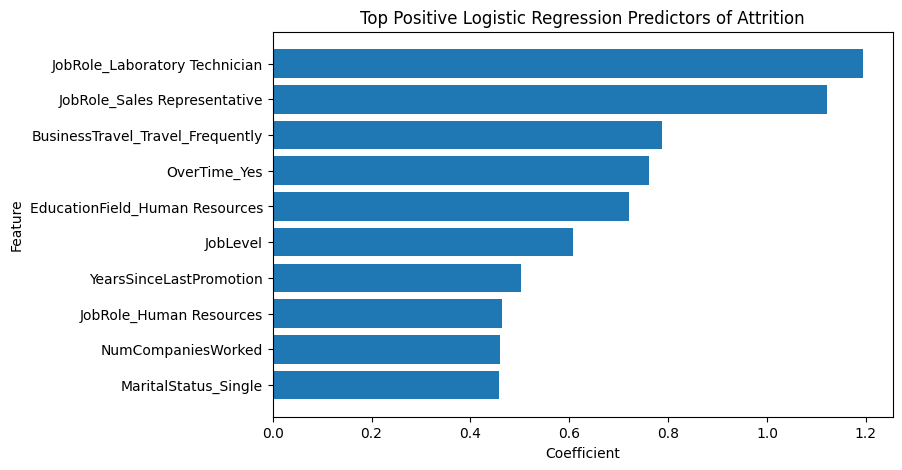

In [108]:
top_positive = log_coef_df.sort_values("Coefficient", ascending=False).head(10)
top_positive = top_positive.sort_values("Coefficient")

plt.figure(figsize=(8, 5))
plt.barh(top_positive["Feature"], top_positive["Coefficient"])
plt.title("Top Positive Logistic Regression Predictors of Attrition")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

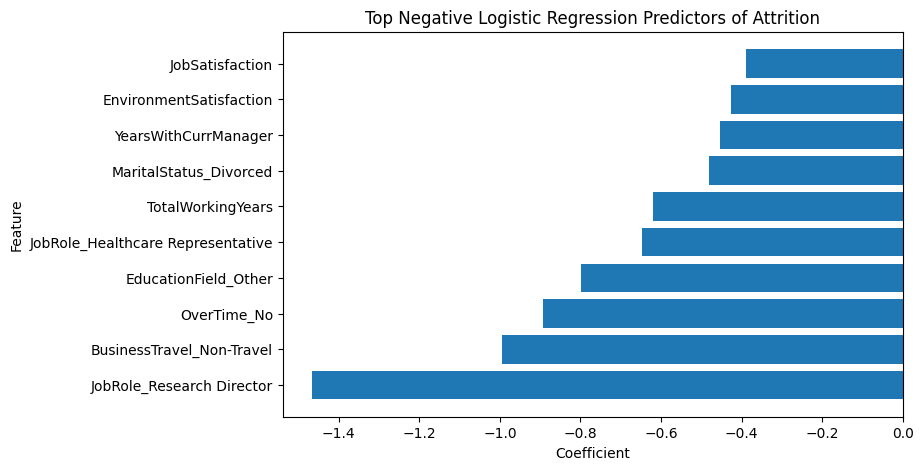

In [109]:
top_negative = log_coef_df.sort_values("Coefficient", ascending=True).head(10)
top_negative = top_negative.sort_values("Coefficient")

plt.figure(figsize=(8, 5))
plt.barh(top_negative["Feature"], top_negative["Coefficient"])
plt.title("Top Negative Logistic Regression Predictors of Attrition")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

Positive coefficients increase the likelihood of attrition, while negative coefficients decrease it. This makes the model easier to explain to HR stakeholders.

###7.2 Random Forest feature importance

Top 15 Random Forest feature importances:


,Feature,Importance
9,MonthlyIncome,0.079202
16,TotalWorkingYears,0.064675
0,Age,0.061120
1,DailyRate,0.045838
19,YearsAtCompany,0.043683
22,YearsWithCurrManager,0.042161
15,StockOptionLevel,0.040162
49,OverTime_No,0.039723
5,HourlyRate,0.039242
10,MonthlyRate,0.038994


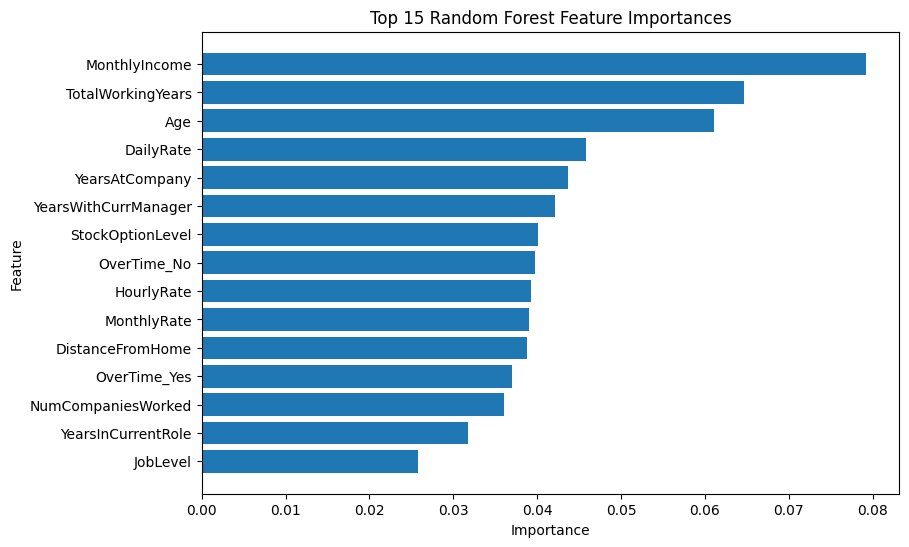

In [110]:
rf_pipe = saved_models["Random Forest (Balanced)"]

rf_feature_names = rf_pipe.named_steps["preprocess"].get_feature_names_out()
rf_importances = rf_pipe.named_steps["model"].feature_importances_

rf_importance_df = pd.DataFrame({"Feature": rf_feature_names,"Importance": rf_importances})

rf_importance_df = rf_importance_df.sort_values("Importance", ascending=False)

rf_importance_df["Feature"] = rf_importance_df["Feature"].str.replace("num__", "", regex=False)
rf_importance_df["Feature"] = rf_importance_df["Feature"].str.replace("cat__", "", regex=False)

print("Top 15 Random Forest feature importances:")
display(rf_importance_df.head(15))

top_rf = rf_importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(9, 6))
plt.barh(top_rf["Feature"], top_rf["Importance"])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 8. Summary tables

In [111]:
print("Overall attrition rate:")
print(round(df["Attrition_Flag"].mean() * 100, 2), "%")

print("\nTop departments by attrition risk:")
display(dept_risk.round(2))

print("\nTop job roles by attrition risk:")
display(jobrole_risk.round(2))

print("\nFinal model comparison table:")
display(results_df_sorted.round(4))

Overall attrition rate:
16.12 %

Top departments by attrition risk:


,Attrition_Flag
Department,
Sales,20.63
Human Resources,19.05
Research & Development,13.84



Top job roles by attrition risk:


,Attrition_Flag
JobRole,
Sales Representative,39.76
Laboratory Technician,23.94
Human Resources,23.08
Sales Executive,17.48
Research Scientist,16.10
Manufacturing Director,6.90
Healthcare Representative,6.87
Manager,4.90
Research Director,2.50



Final model comparison table:


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC
0,Logistic Regression (No Class Weight),0.8903,0.7763,0.4421,0.5610,0.8392,0.8605,0.6154,0.3404,0.4384,0.8115
1,Gradient Boosting (XGBoost),0.8214,0.4636,0.6000,0.5194,0.8116,0.7959,0.3934,0.5106,0.4444,0.7728
2,Logistic Regression (Balanced),0.7534,0.3721,0.7368,0.4925,0.8273,0.7517,0.3488,0.6383,0.4511,0.8032
3,Decision Tree (No Class Weight),0.8376,0.4879,0.3053,0.3699,0.6658,0.8367,0.4737,0.1915,0.2727,0.6618
4,Random Forest (Balanced),0.8639,0.7290,0.2474,0.3627,0.7907,0.8333,0.4545,0.2128,0.2899,0.7923
5,Decision Tree (Balanced),0.6964,0.2608,0.4684,0.3315,0.6264,0.7857,0.3788,0.5319,0.4425,0.6527
6,Random Forest (No Class Weight),0.8597,0.8367,0.1789,0.2855,0.8129,0.8435,0.5556,0.1064,0.1786,0.7974


### 8.1 Best Model Summary Table

In [112]:
best_model_summary = results_df_sorted.iloc[0][[
    "Model", "CV Accuracy", "CV Precision", "CV Recall", "CV F1", "CV ROC AUC",
    "Test Accuracy", "Test Precision", "Test Recall", "Test F1", "Test ROC AUC"]].to_frame(name="Best Model Value")

print("\nBest model summary:")
display(best_model_summary.round(4))


Best model summary:


,Best Model Value
Model,Logistic Regression (No Class Weight)
CV Accuracy,0.89031
CV Precision,0.77635
CV Recall,0.442105
CV F1,0.561011
CV ROC AUC,0.839189
Test Accuracy,0.860544
Test Precision,0.615385
Test Recall,0.340426
Test F1,0.438356
